# MDE 是什么？怎么算出来的？

## —— 写给不懂统计学的业务同学

> 一句话先记住：**MDE = 我们的测量工具能"看清"的最小变化。比它小的变化，会被数据天然的"抖动"淹没，看不出来。**

---

### 这份文档想解决的困惑

业务里我们经常说：
- "满意率这周 70%，上周 71%，是不是变差了？"
- "做了个改动，转化率涨了 0.3%，到底算不算涨了？"

很多时候答案是：**这点变化分辨不出来，因为它比数据本身的随机抖动还小。**

MDE（Minimum Detectable Effect，最小可检测变化）就是用来回答：

> **"在当前样本量下，至少要变多少，我们才敢说'它真的变了'？"**

下面我们用 7 步、配图，把这件事讲清楚。每一步都先讲直觉，再看图，最后才出公式。

| 步骤 | 讲什么 |
|------|--------|
| 1 | 一个生活比喻：听不清的悄悄话 |
| 2 | 指标天生会"抖"（抽样噪声） |
| 3 | 样本越多，抖动越小 |
| 4 | MDE 正式登场：信号要盖过噪声 |
| 5 | 拆开公式：MDE = Z × 标准误 |
| 6 | Z 是什么？（置信度 + 把握度） |
| 7 | 反过来：定好 MDE，倒推要多少样本 |
| 附 | 多个页面如何合成"整体 MDE" |

In [18]:
# === 环境准备（运行一次即可）===
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats

# 让图里的中文正常显示（自动挑选系统里可用的中文字体）
import matplotlib.font_manager as fm
_zh_candidates = ["PingFang HK", "PingFang SC", "Heiti TC", "Songti SC",
                  "Arial Unicode MS", "STHeiti", "Microsoft YaHei", "SimHei"]
_available = {f.name for f in fm.fontManager.ttflist}
_zh_font = next((f for f in _zh_candidates if f in _available), None)
if _zh_font:
    matplotlib.rcParams["font.sans-serif"] = [_zh_font]
matplotlib.rcParams["axes.unicode_minus"] = False  # 负号正常显示
plt.rcParams["figure.dpi"] = 110

np.random.seed(42)  # 固定随机数，保证每次结果一致
print("环境就绪 ✓  中文字体：", _zh_font or "未找到中文字体，图里中文可能显示为方块")

环境就绪 ✓  中文字体： PingFang HK


## 第 1 步：一个生活比喻 —— 听不清的悄悄话

想象你在一个**有背景噪音**的房间里听别人说话：

- 背景一直有"沙沙"的杂音（这就是数据的**随机抖动 / 噪声**）。
- 对方说话太小声，你就听不清，分辨不出他到底说了什么。
- 只有他说得**足够大声**，盖过背景杂音，你才能确定听到了内容。

> **MDE 就是"能被听清的最小音量"。**
>
> - 背景越吵（数据抖动越大）→ 需要说得越大声（MDE 越大，越难发现小变化）。
> - 你越用心听、听的时间越长（样本量越大）→ 背景显得越安静（MDE 越小，越能发现细微变化）。

把"听声音"换成"看指标变化"，整个故事完全一样。下面我们用真实数据把这个比喻画出来。

## 第 2 步：指标天生就会"抖" —— 抽样噪声

先做个关键澄清：**就算用户的真实满意率一点没变，你每天测出来的数字也不会是同一个数。**

为什么？因为我们不可能问遍所有人，只能**每天抽一部分用户**来问。抽到的人不同，算出来的满意率自然会上下浮动。这就是"抽样噪声"。

下面我们做个模拟实验：假设**真实满意率永远是 70%（一条直线，从没变过）**，但我们每天随机抽 `n=500` 个用户来测，看看测出来的数字长什么样。

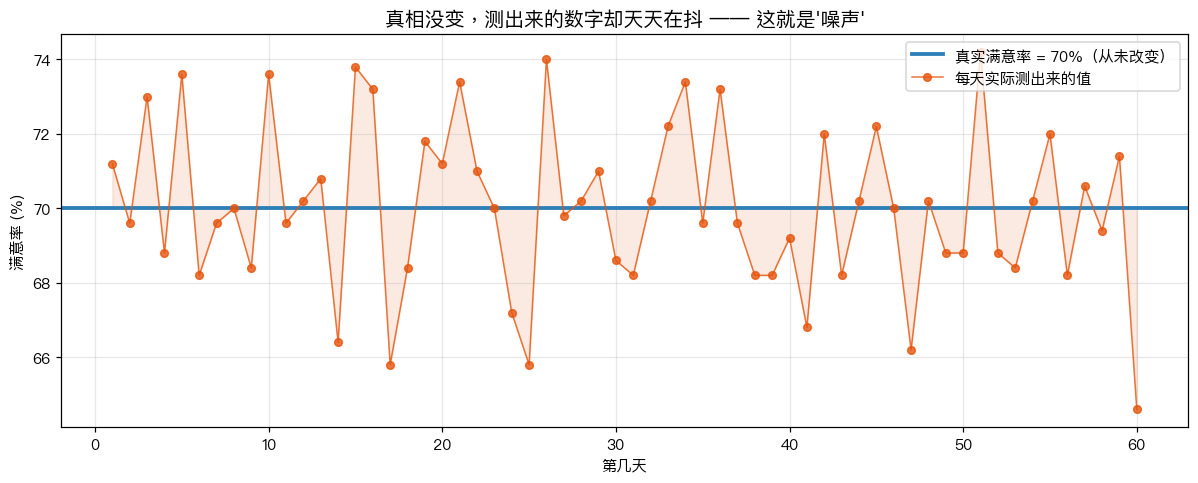

60 天里，真实值一直是 70%，但测出来的范围是 64.6% ~ 74.2%
→ 看到 71% 不代表变好，看到 69% 也不代表变差，很可能只是抖动！


In [19]:
# 模拟：真实满意率恒定为 70%，但每天抽 500 人测量
p_true = 0.70      # 真实满意率（上帝视角，现实中我们不知道）
n = 500            # 每天抽样人数
days = 60          # 观测 60 天

# 每天抽 n 个用户，统计满意人数比例
daily_measured = np.random.binomial(n, p_true, size=days) / n

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axhline(p_true*100, color="#2c7fb8", lw=2.5, label=f"真实满意率 = {p_true*100:.0f}%（从未改变）")
ax.plot(range(1, days+1), daily_measured*100, "o-", color="#e6550d",
        ms=5, lw=1, alpha=0.8, label="每天实际测出来的值")
ax.fill_between(range(1, days+1), p_true*100, daily_measured*100,
                color="#e6550d", alpha=0.12)
ax.set_xlabel("第几天")
ax.set_ylabel("满意率 (%)")
ax.set_title("真相没变，测出来的数字却天天在抖 —— 这就是'噪声'", fontsize=13)
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"60 天里，真实值一直是 70%，但测出来的范围是 "
      f"{daily_measured.min()*100:.1f}% ~ {daily_measured.max()*100:.1f}%")
print("→ 看到 71% 不代表变好，看到 69% 也不代表变差，很可能只是抖动！")

## 第 3 步：样本越多，抖动越小

那能不能让数字别抖得那么厉害？能 —— **多抽点人就行。**

直觉理解：问 10 个人，1 个人改主意就能让比例跳动 10%；问 10000 个人，1 个人的影响微乎其微。**抽的人越多，偶然因素被"平均"掉得越多，结果越稳。**

下面把每天抽 `100 / 500 / 5000` 人的三种情况画在一起，真实值同样恒定 70%，看抖动带的宽窄。

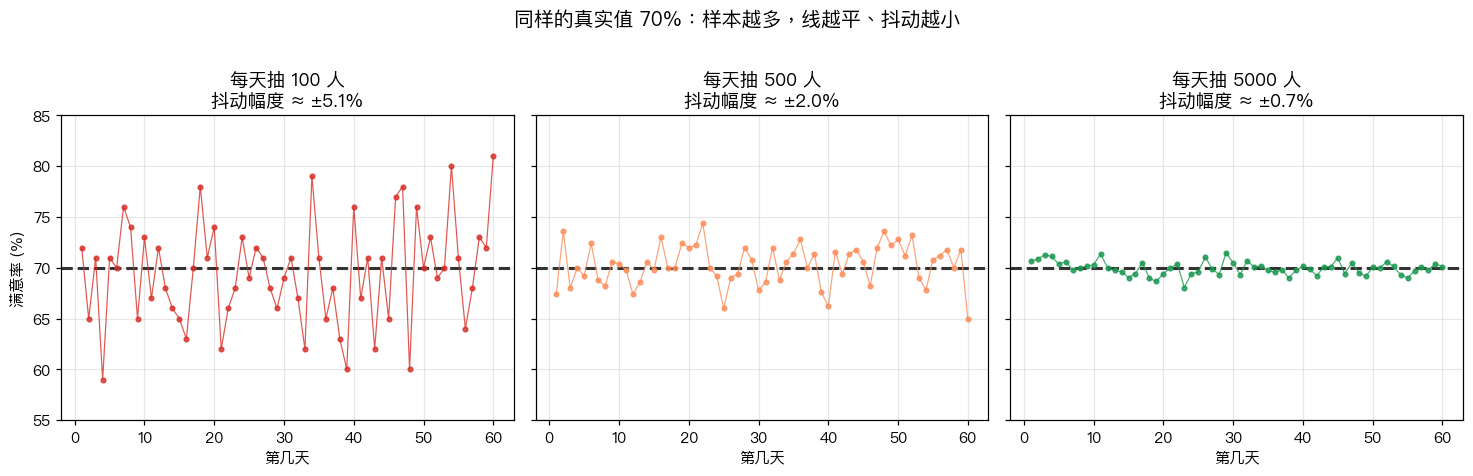

规律：样本量翻 4 倍，抖动大约缩小一半（抖动 ∝ 1/√样本量）。
这条规律是后面 MDE 公式的核心。


In [20]:
# 对比不同样本量下，测量值的抖动幅度
p_true = 0.70
days = 60
sample_sizes = [100, 500, 5000]
colors = ["#d73027", "#fc8d59", "#1a9850"]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True)
for ax, n, c in zip(axes, sample_sizes, colors):
    measured = np.random.binomial(n, p_true, size=days) / n
    ax.axhline(p_true*100, color="#333", lw=2, ls="--")
    ax.plot(range(1, days+1), measured*100, "o-", color=c, ms=3, lw=0.8, alpha=0.8)
    spread = measured.std() * 100
    ax.set_title(f"每天抽 {n} 人\n抖动幅度 ≈ ±{spread:.1f}%", fontsize=12)
    ax.set_xlabel("第几天")
    ax.set_ylim(55, 85)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("满意率 (%)")
fig.suptitle("同样的真实值 70%：样本越多，线越平、抖动越小", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("规律：样本量翻 4 倍，抖动大约缩小一半（抖动 ∝ 1/√样本量）。")
print("这条规律是后面 MDE 公式的核心。")

## 第 4 步：MDE 正式登场 —— 变化要"盖过"噪声才算数

现在把两件事放一起：

1. 数据本身有一团"抖动"（噪声）。
2. 我们想知道指标**真的变了**没有。

道理很简单：**真实的变化必须大到能从这团抖动里"冒出来"，我们才敢确认它。**

- 如果真实变化很小（比如 70% → 70.3%），它会被淹没在抖动里，根本分不清是"真的变了"还是"今天碰巧抖到这"。
- 如果真实变化够大（比如 70% → 75%），它明显超出了平时的抖动范围，我们就能确认。

**那个刚好能被分辨出来的"临界变化幅度"，就是 MDE。**

下图：左边是"没变化时"测量值的抖动分布。我们把 MDE 画成一条线 —— 只有变化大到这条线之外，才算"看得见"。

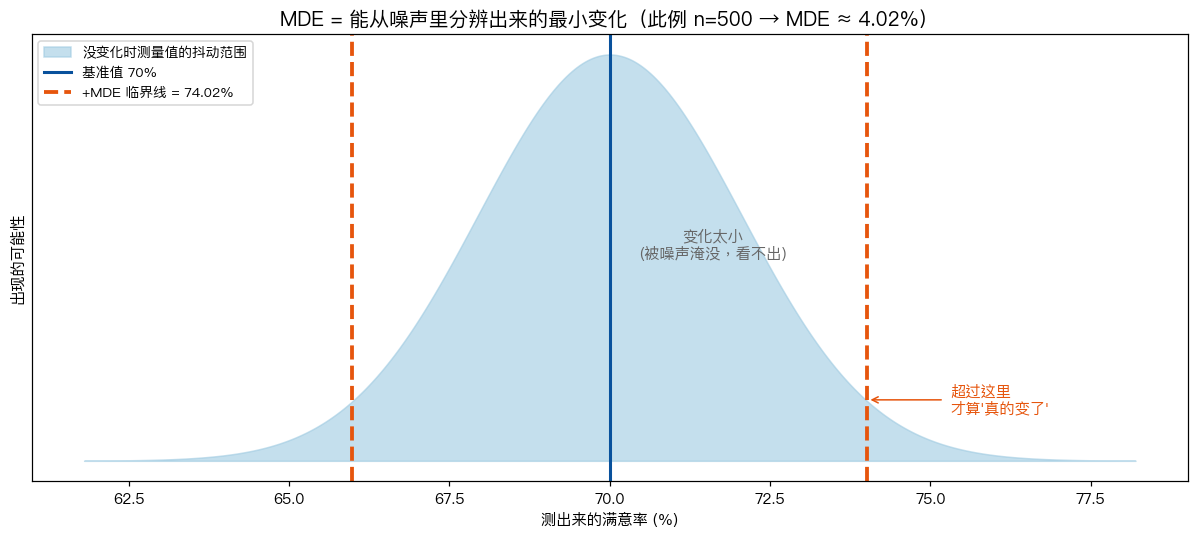

解读：当每天抽 500 人时，满意率至少要变 ±4.02 个百分点，
     我们才敢确认'真的变了'。变化小于 4.02% 的，分辨不出来。


In [21]:
# 直观展示：噪声分布 + MDE 临界线
p = 0.70
n = 500
Z = 1.96  # 先用最常见的取值，下一步详细解释它

se = np.sqrt(p*(1-p)/n)     # 标准误：衡量"噪声有多大"
mde = Z * se                # MDE = Z × 标准误

x = np.linspace(p-4*se, p+4*se, 400)
noise = stats.norm.pdf(x, p, se)

fig, ax = plt.subplots(figsize=(11, 5))
# 噪声分布（没有真实变化时，测量值会落在这里）
ax.fill_between(x*100, noise, color="#9ecae1", alpha=0.6, label="没变化时测量值的抖动范围")
ax.axvline(p*100, color="#08519c", lw=2, label=f"基准值 {p*100:.0f}%")

# MDE 临界线
ax.axvline((p+mde)*100, color="#e6550d", lw=2.5, ls="--",
           label=f"+MDE 临界线 = {(p+mde)*100:.2f}%")
ax.axvline((p-mde)*100, color="#e6550d", lw=2.5, ls="--")

# 标注：太小的变化 vs 够大的变化
ax.annotate("变化太小\n(被噪声淹没，看不出)", xy=((p+0.4*mde)*100, noise.max()*0.5),
            ha="center", fontsize=10, color="#666")
ax.annotate("", xy=((p+mde)*100, noise.max()*0.15), xytext=((p+mde+0.012)*100, noise.max()*0.15),
            arrowprops=dict(arrowstyle="->", color="#e6550d"))
ax.text((p+mde+0.013)*100, noise.max()*0.15, "超过这里\n才算'真的变了'",
        fontsize=10, color="#e6550d", va="center")

ax.set_xlabel("测出来的满意率 (%)")
ax.set_ylabel("出现的可能性")
ax.set_title(f"MDE = 能从噪声里分辨出来的最小变化（此例 n={n} → MDE ≈ {mde*100:.2f}%）", fontsize=13)
ax.legend(loc="upper left", fontsize=9)
ax.set_yticks([])
plt.tight_layout()
plt.show()

print(f"解读：当每天抽 {n} 人时，满意率至少要变 ±{mde*100:.2f} 个百分点，")
print(f"     我们才敢确认'真的变了'。变化小于 {mde*100:.2f}% 的，分辨不出来。")

## 第 5 步：拆开公式 —— MDE 只由两块拼成

到这里可以亮出公式了，它其实很友好，只有两个零件相乘：

$$
\textbf{MDE} \;=\; \underbrace{Z}_{\text{要多严格}} \;\times\; \underbrace{\sqrt{\dfrac{p(1-p)}{n}}}_{\text{噪声有多大（标准误 SE）}}
$$

**零件一：标准误 SE（噪声大小）** = $\sqrt{\dfrac{p(1-p)}{n}}$

- $p(1-p)$：指标本身的"不确定性"。$p=50\%$ 时最不确定（最难猜），越接近 0% 或 100% 越确定。
- $n$：样本量。**它在分母的根号里，所以样本越多，噪声越小**（呼应第 3 步）。

**零件二：Z（你要多严格）**

- 一个倍数，代表你想要多高的"确信度"。要求越严格 → Z 越大 → MDE 越大（下一步专门讲它）。
- 最常用 $Z=1.96$。

下面用真实数字，一步步把 MDE 算出来，并用条形图看清"两块零件"各占多少。

【一步步计算 MDE】
① 指标的不确定性  p(1-p) = 0.7 × 0.30000000000000004 = 0.2100
② 除以样本量      0.2100 / 500 = 0.00042000
③ 开根号 = 标准误 SE = √0.00042000 = 0.02049  （即 ±2.05%）
④ 乘以严格度 Z    MDE = 1.96 × 0.02049 = 0.04017
----------------------------------------------------
  ✅ MDE ≈ 4.02%
  含义：满意率至少要变 ±4.02 个百分点，才能确认'真的变了'


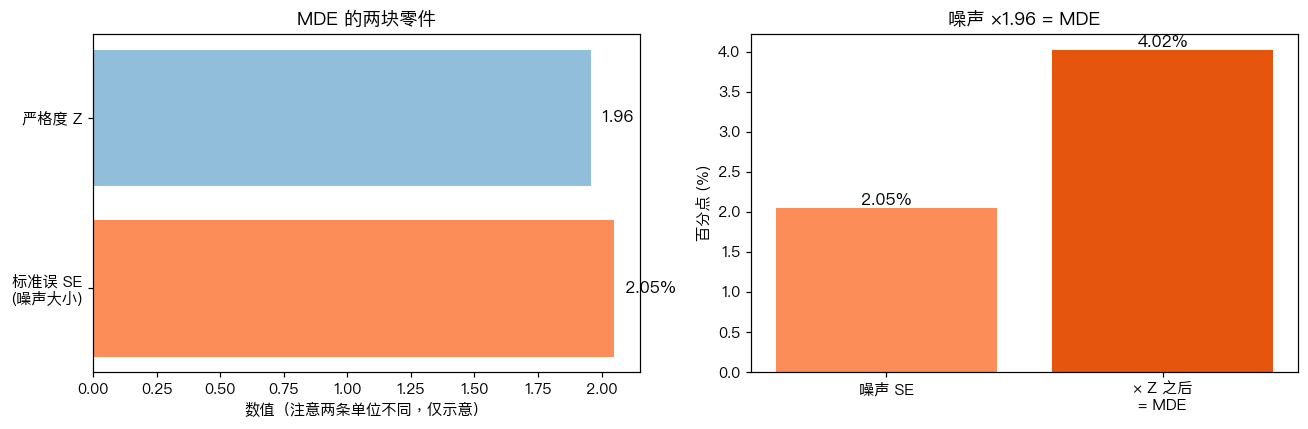

In [22]:
# 一步步把 MDE 算出来（改这三个值，立刻得到你自己的 MDE）
p = 0.70   # 当前指标比例（满意率/转化率）
n = 500    # 样本量
Z = 1.96   # 严格程度（下一步解释，先用 1.96）

print("="*52)
print("【一步步计算 MDE】")
print("="*52)
var = p * (1 - p)
print(f"① 指标的不确定性  p(1-p) = {p} × {1-p} = {var:.4f}")
print(f"② 除以样本量      {var:.4f} / {n} = {var/n:.8f}")
se = np.sqrt(var / n)
print(f"③ 开根号 = 标准误 SE = √{var/n:.8f} = {se:.5f}  （即 ±{se*100:.2f}%）")
mde = Z * se
print(f"④ 乘以严格度 Z    MDE = {Z} × {se:.5f} = {mde:.5f}")
print("-"*52)
print(f"  ✅ MDE ≈ {mde*100:.2f}%")
print(f"  含义：满意率至少要变 ±{mde*100:.2f} 个百分点，才能确认'真的变了'")
print("="*52)

# 可视化：MDE 由 Z 和 SE 相乘而成
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 左图：两块零件
ax1.barh(["标准误 SE\n(噪声大小)", "严格度 Z"], [se*100, Z], color=["#fc8d59", "#91bfdb"])
ax1.text(se*100, 0, f"  {se*100:.2f}%", va="center", fontsize=11)
ax1.text(Z, 1, f"  {Z}", va="center", fontsize=11)
ax1.set_title("MDE 的两块零件")
ax1.set_xlabel("数值（注意两条单位不同，仅示意）")

# 右图：相乘得到 MDE
ax2.bar(["噪声 SE", "× Z 之后\n= MDE"], [se*100, mde*100],
        color=["#fc8d59", "#e6550d"])
ax2.text(0, se*100, f"{se*100:.2f}%", ha="center", va="bottom", fontsize=11)
ax2.text(1, mde*100, f"{mde*100:.2f}%", ha="center", va="bottom", fontsize=11)
ax2.set_title(f"噪声 ×{Z} = MDE")
ax2.set_ylabel("百分点 (%)")
plt.tight_layout()
plt.show()

## 第 6 步：Z 是什么？—— "你要多严格"的旋钮

Z 是公式里唯一带点统计味的零件，但本质很好懂：**它是一个把"你要多严格"翻译成数字的旋钮。** Z 越大 = 要求越严格 = 需要变化更大才肯下结论。

它由两个业务能理解的"把握度"决定：

| 名字 | 通俗说法 | 常用值 | 对应 Z 分量 |
|------|----------|--------|-------------|
| 显著性 α | "我不想虚惊一场"：没变化却误判成变了的概率，要控制得很低 | 5% | $Z_{\alpha/2}=1.96$ |
| 功效 Power | "我不想错过真变化"：真的变了，我有多大把握能抓到 | 80% | $Z_{\beta}=0.84$ |

工具里的 Z 其实是两者相加：

$$
Z = Z_{\alpha/2} + Z_{\beta}
$$

- 只要求"不虚惊"(α=5%)：$Z=1.96$
- 同时要求"不错过"(α=5%, Power=80%)：$Z=1.96+0.84=2.80$

**要求越高，Z 越大，MDE 也越大** —— 想要又稳又不漏，就得接受"能看清的最小变化"变大（或者去堆更多样本）。下图直观展示这两个"把握度"。

> 💡 **看图提示**：这张图**主要看阴影面积（概率）**，横轴只是用来定位「判定线」在哪。图下方有专门的解读说明。

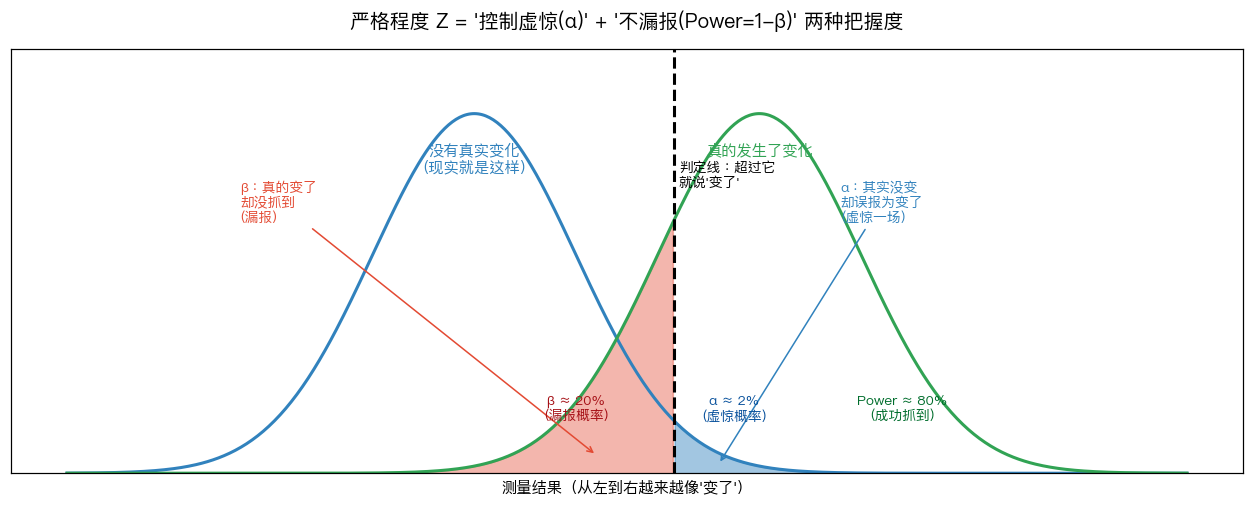

不同'严格程度'下的 Z（样本 n=500, p=70% 时的 MDE）：
  只要不虚惊 (α=5%)                           Z=1.96  →  MDE ≈ 4.02%
  不虚惊+八成把握抓到 (α=5%,Power=80%)            Z=2.80  →  MDE ≈ 5.74%
  更严格 (α=5%,Power=90%)                   Z=3.24  →  MDE ≈ 6.64%


In [23]:
# 用两条钟形曲线解释 α(不虚惊) 和 Power(不错过)
se = 1.0
mu0, mu1 = 0, 2.8 * se  # 左:没变化  右:真的变了
x = np.linspace(-4, 7, 600)
d0 = stats.norm.pdf(x, mu0, se)
d1 = stats.norm.pdf(x, mu1, se)
thr = 1.96 * se  # 判定阈值

fig, ax = plt.subplots(figsize=(11.5, 5))
ax.plot(x, d0, color="#3182bd", lw=2)
ax.plot(x, d1, color="#31a354", lw=2)
ax.fill_between(x, d0, where=(x >= thr), color="#3182bd", alpha=0.45)  # α 误报
ax.fill_between(x, d1, where=(x < thr), color="#e34a33", alpha=0.40)   # β 漏报
ax.axvline(thr, color="#000", lw=2, ls="--")

# 算出三块面积对应的概率，直接标在图上（这张图主要看面积，不是看横轴刻度）
alpha_pct = (1 - stats.norm.cdf(thr, mu0, se)) * 100
beta_pct = stats.norm.cdf(thr, mu1, se) * 100
power_pct = 100 - beta_pct

peak = d0.max()
ax.text(mu0, peak*0.92, "没有真实变化\n（现实就是这样）", ha="center", va="top", color="#3182bd", fontsize=10)
ax.text(mu1, peak*0.92, "真的发生了变化", ha="center", va="top", color="#31a354", fontsize=10)
ax.text(thr+0.05, peak*0.80, "判定线：超过它\n就说'变了'", fontsize=9)
ax.annotate("α：其实没变\n却误报为变了\n(虚惊一场)", xy=(2.4, 0.01), xytext=(3.6, 0.28),
            fontsize=9, color="#3182bd", arrowprops=dict(arrowstyle="->", color="#3182bd"))
ax.annotate("β：真的变了\n却没抓到\n(漏报)", xy=(1.2, 0.02), xytext=(-2.3, 0.28),
            fontsize=9, color="#e34a33", arrowprops=dict(arrowstyle="->", color="#e34a33"))
ax.text(2.55, 0.06, f"α ≈ {alpha_pct:.0f}%\n(虚惊概率)", ha="center", fontsize=9, color="#08519c")
ax.text(1.0, 0.06, f"β ≈ {beta_pct:.0f}%\n(漏报概率)", ha="center", fontsize=9, color="#a50f15")
ax.text(4.2, 0.06, f"Power ≈ {power_pct:.0f}%\n(成功抓到)", ha="center", fontsize=9, color="#006d2c")

# 顶部留白，避免标题压住曲线和文字
ax.set_ylim(0, peak*1.18)
ax.set_title("严格程度 Z = '控制虚惊(α)' + '不漏报(Power=1-β)' 两种把握度",
             fontsize=13, pad=14)
ax.set_yticks([]); ax.set_xticks([])
ax.set_xlabel("测量结果（从左到右越来越像'变了'）")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# 不同严格程度对应的 Z 和 MDE
print("不同'严格程度'下的 Z（样本 n=500, p=70% 时的 MDE）：")
p, n = 0.70, 500
se_real = np.sqrt(p*(1-p)/n)
for desc, Zval in [("只要不虚惊 (α=5%)", 1.96),
                   ("不虚惊+八成把握抓到 (α=5%,Power=80%)", 2.80),
                   ("更严格 (α=5%,Power=90%)", 1.96+1.28)]:
    print(f"  {desc:38s} Z={Zval:.2f}  →  MDE ≈ {Zval*se_real*100:.2f}%")

### 📖 这张图怎么看？—— 主要看「面积」，横轴只是定位

很多人第一眼会盯着横轴，其实**真正有意义的是被判定线切出来的三块阴影面积**。

| 图上元素 | 它代表什么 | 你要关注什么 |
|----------|------------|--------------|
| **横轴** | 一次实验测出来的结果（从左到右越来越像"变了"） | 只用来理解**判定线画在哪**；刻度本身不是重点 |
| **黑色虚线（判定线）** | 超过它就说"变了"，没超过就说"没变" | 线的位置 = 你有多严格（对应 Z / α） |
| **蓝色曲线** | "其实没变"时，结果会怎么分布 | 看曲线**右侧**被切出的蓝色面积 |
| **绿色曲线** | "真的变了"时，结果会怎么分布 | 看曲线**左侧**红色面积、**右侧**未着色面积 |

**三块面积 = 三种概率：**

| 颜色块 | 含义 | 统计名 | 业务白话 |
|--------|------|--------|----------|
| 🔵 蓝色阴影（蓝曲线、线右边） | 其实没变，却误判成"变了" | **α**（显著性） | 虚惊一场 |
| 🔴 红色阴影（绿曲线、线左边） | 真的变了，却没抓到 | **β**（第二类错误） | 漏报 |
| 🟢 绿曲线、线右边（未着色） | 真的变了，且成功抓到 | **Power = 1−β**（功效） | 不错过真变化 |

> **一句话记忆：横轴定「判定线在哪」，面积才是「犯错的概率」。**
>
> 移动判定线（调 Z）就是在两块阴影之间做权衡：线往右移 → 蓝色面积变小（少虚惊），但红色面积变大（多漏报）。Z 就是把这两种把握度合成一个数字的旋钮。

## 第 7 步：反过来用 —— 定好 MDE，倒推要多少样本（单样本也含 Power）

在**单样本波动观测**里，也可以反着问：

> "我希望能发现 ±1% 的波动（目标 MDE = 1%），并且希望有 80% 把握抓到它，需要多少样本？"

核心仍是：

$$
\text{MDE} = Z_{\text{total}}\sqrt{\dfrac{p(1-p)}{n}}
$$

但这里的严格程度不再只用 `1.96`，而是：

$$
Z_{\text{total}} = z_{1-\alpha/2} + z_{\text{Power}}
$$

所以反推样本量为：

$$
\boxed{\,n = \dfrac{(z_{1-\alpha/2}+z_{\text{Power}})^2 \cdot p(1-p)}{\text{MDE}^2}\,}
$$

- `α`：控制"虚惊"（没变却报变）
- `Power`：控制"不漏报"（真变时抓得到）

关键直觉（MDE 在分母且是平方）：

- 想看清的变化**小一半**（MDE 砍半）→ 需要样本量**翻 4 倍**。
- 在同一 MDE 下，把 Power 要求从 50% 提到 80%/90%，样本也会明显增加。

下图用 `α=5%`、`Power=80%` 展示"目标 MDE"与"需要样本量"的关系。

参数：p=70%, alpha=5%, power=80%
对应 Z_total = z_(1-alpha/2)+z_power = 1.96+0.84 = 2.80
目标 MDE  →  需要样本量 n
--------------------------------------------
  ±   3%   →   约    1,831 个样本
  ±   2%   →   约    4,121 个样本
  ±   1%   →   约   16,483 个样本
  ± 0.5%   →   约   65,931 个样本

对比（目标 ±1%）：只控 alpha 约 8,067，加入 power 后约 16,483（更稳妥）


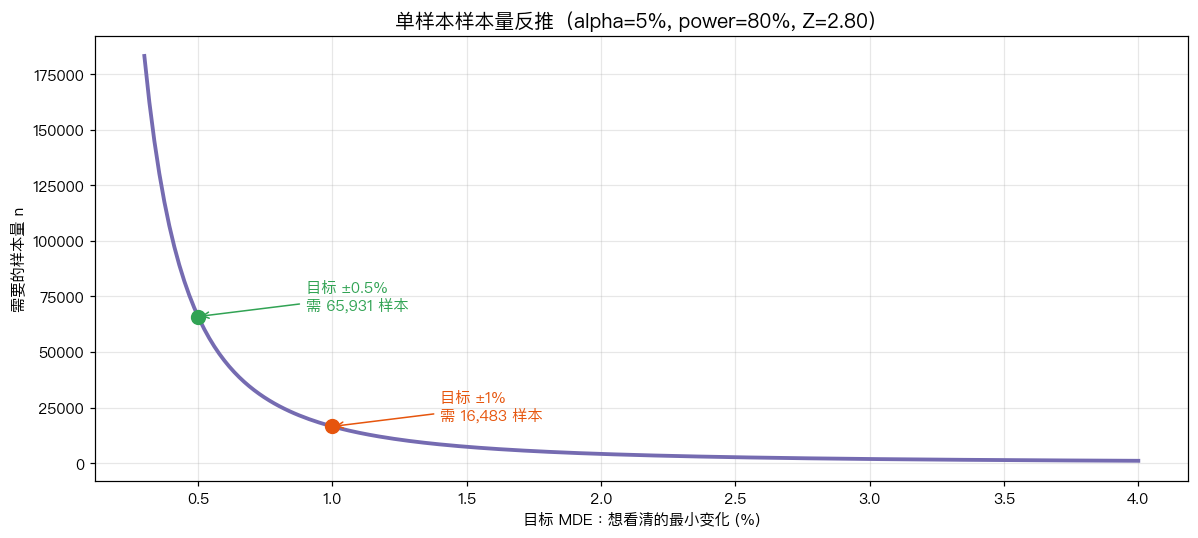

In [24]:
# 反推：给定目标 MDE，算需要多少样本（单样本：显式纳入 alpha + power）
p = 0.70
alpha = 0.05
power = 0.80

# 单样本双侧检测：先控虚惊(alpha)，再保证抓到变化(power)
z_alpha = stats.norm.ppf(1 - alpha/2)
z_power = stats.norm.ppf(power)
Z_total = z_alpha + z_power

def n_needed(mde, p=0.70, Z_total=2.80):
    return Z_total**2 * p*(1-p) / mde**2

# 先看几个具体目标
print(f"参数：p={p:.0%}, alpha={alpha:.0%}, power={power:.0%}")
print(f"对应 Z_total = z_(1-alpha/2)+z_power = {z_alpha:.2f}+{z_power:.2f} = {Z_total:.2f}")
print("目标 MDE  →  需要样本量 n")
print("-"*44)
for mde_pct in [3, 2, 1, 0.5]:
    nn = n_needed(mde_pct/100, p, Z_total)
    print(f"  ±{mde_pct:>4}%   →   约 {nn:>8,.0f} 个样本")

# 对比：同样是 ±1%，只控 alpha 与加入 power 的差异
n_alpha_only = n_needed(0.01, p, z_alpha)
n_with_power = n_needed(0.01, p, Z_total)
print(f"\n对比（目标 ±1%）：只控 alpha 约 {n_alpha_only:,.0f}，加入 power 后约 {n_with_power:,.0f}（更稳妥）")

# 画曲线
mde_axis = np.linspace(0.3, 4, 200) / 100
n_axis = n_needed(mde_axis, p, Z_total)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(mde_axis*100, n_axis, color="#756bb1", lw=2.5)
for mde_pct, col in [(1, "#e6550d"), (0.5, "#31a354")]:
    nn = n_needed(mde_pct/100, p, Z_total)
    ax.plot([mde_pct], [nn], "o", color=col, ms=9)
    ax.annotate(f"目标 ±{mde_pct}%\n需 {nn:,.0f} 样本",
                xy=(mde_pct, nn), xytext=(mde_pct+0.4, nn+3000),
                fontsize=10, color=col,
                arrowprops=dict(arrowstyle="->", color=col))
ax.set_xlabel("目标 MDE：想看清的最小变化 (%)")
ax.set_ylabel("需要的样本量 n")
ax.set_title(f"单样本样本量反推（alpha={alpha:.0%}, power={power:.0%}, Z={Z_total:.2f}）", fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 附：多个页面如何合成"整体 MDE"

我们的工具有个进阶场景：整体指标其实是 **L / D / B / O / M 五个页面** 按权重拼起来的。每个页面流量不同、占比不同，但业务只关心**整体满意率的 MDE**。

直觉理解，分三句话：

1. **每个页面都有自己的一份"噪声"**，页面占整体的权重越大、自己样本越少，它带来的噪声就越多。
2. **整体噪声不是简单相加**，而是把各页噪声按 $w_i^2$ 加权后求和、再开根号（方差可加，标准差不能直接加）：

$$
\text{整体 MDE} = Z\sqrt{\sum_i w_i^2\cdot\dfrac{p_i(1-p_i)}{n_i}}
$$

3. **反推时**：先定整体目标 δ，把"总噪声预算" $\delta^2/Z^2$ 按权重比例分给各页，权重大的页面分到更多预算、也就需要更多样本。

下面用一个两页例子（高权重页 + 低权重页）把"整体 MDE 由各页噪声合成"画出来。

整体目标 MDE = 1%
  页面A(高权重): 权重 90% → 需样本 7,261，贡献噪声份额 90%
  页面B(低权重): 权重 10% → 需样本 807，贡献噪声份额 10%
  合成回算的整体 MDE = 1.000%  （≈ 目标 1%，✓ 对上了）


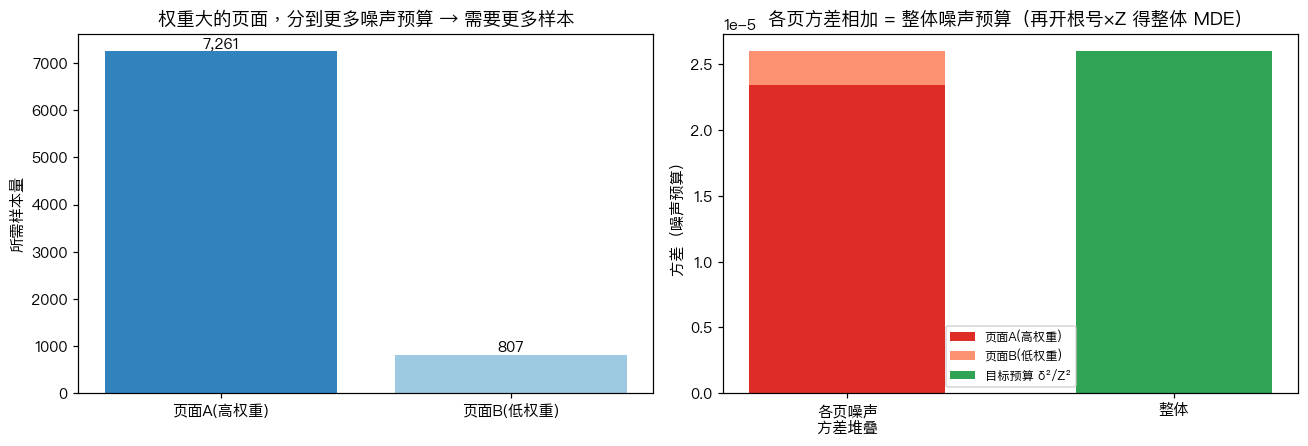

In [25]:
# 多页面：方差预算按权重分配，再合成整体 MDE（对应工具方法论）
Z = 1.96
delta = 0.01            # 整体目标 MDE = 1%
pages = ["页面A(高权重)", "页面B(低权重)"]
w = np.array([0.90, 0.10])      # 权重
p = np.array([0.70, 0.70])      # 各页比例

# 反推：方差预算按权重比例分配 → 各页所需样本量
budget = delta**2 / Z**2                       # 总噪声预算
share = w / w.sum()                            # 各页预算份额
n_each = w * w.sum() * p*(1-p) * Z**2 / delta**2   # 方法论里的反推公式
var_each = w**2 * p*(1-p) / n_each             # 各页贡献的方差（误差份额）
overall_mde = Z * np.sqrt(var_each.sum())      # 合成整体 MDE

print(f"整体目标 MDE = {delta*100:.0f}%")
for i, name in enumerate(pages):
    print(f"  {name}: 权重 {w[i]:.0%} → 需样本 {n_each[i]:,.0f}，"
          f"贡献噪声份额 {share[i]:.0%}")
print(f"  合成回算的整体 MDE = {overall_mde*100:.3f}%  （≈ 目标 1%，✓ 对上了）")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
ax1.bar(pages, n_each, color=["#3182bd", "#9ecae1"])
for i, v in enumerate(n_each):
    ax1.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=10)
ax1.set_title("权重大的页面，分到更多噪声预算 → 需要更多样本")
ax1.set_ylabel("所需样本量")

# 各页方差堆叠成整体
ax2.bar(["各页噪声\n方差堆叠", "整体"], [var_each.sum(), 0], color="#fee0d2", width=0.6)
bottom = 0
for i, name in enumerate(pages):
    ax2.bar(["各页噪声\n方差堆叠"], [var_each[i]], bottom=[bottom],
            color=["#de2d26", "#fc9272"][i], label=name, width=0.6)
    bottom += var_each[i]
ax2.bar(["整体"], [budget], color="#31a354", width=0.6, label="目标预算 δ²/Z²")
ax2.set_title("各页方差相加 = 整体噪声预算（再开根号×Z 得整体 MDE）")
ax2.set_ylabel("方差（噪声预算）")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 一页总结（可以截图给业务）

**MDE = 在当前样本量下，我们能"看清"的最小变化。** 比它小的变化，会被数据天然的抖动淹没，无法确认。

记住三件事就够了：

1. **数据天生会抖**（抽样噪声）。看到 70%→71% 不一定是真变了，可能只是抖动。
2. **MDE 由两块拼成**：
   $$\text{MDE} = \underbrace{Z}_{\text{你要多严格}} \times \underbrace{\sqrt{\tfrac{p(1-p)}{n}}}_{\text{噪声大小}}$$
   - 样本 `n` 越大 → 噪声越小 → MDE 越小 → 越能发现细微变化。
   - 要求越严格（Z 越大）→ MDE 越大。
3. **精度很贵**：想看清的变化砍一半，需要的样本量要翻 4 倍。

**和工具的关系**：

- 工具的 Mode 2 是正着算：给样本量 `n` → 算出能看清多少（MDE）。
- 工具的 Mode 1 是反着算：给目标精度 δ（=目标 MDE）→ 倒推每个页面需要多少样本。
- 多页面时，整体 MDE 由各页噪声按权重平方加权合成；反推时按权重把噪声预算分给各页。

> 给业务的一句话：**"MDE 就是这套数据能看清的最小刻度。想看得更细，要么忍受更大的刻度，要么花更多样本把刻度磨细。"**

---

*配套方法论文档：`page-sample-size-methodology.md`　|　配套工具：`index.html`（样本量计算器）*